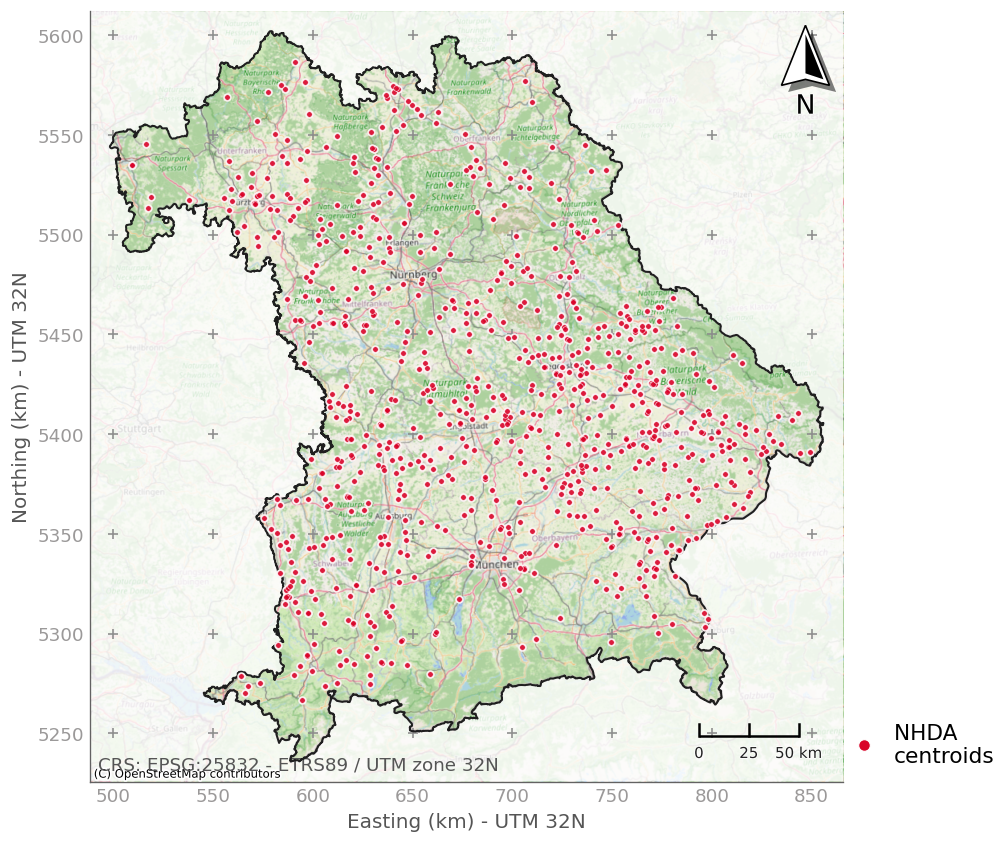

NHDA features in Bavaria: 839
Saved map: C:\Users\agz90fk\Documents\Masterarbeit\06_Abbildungen\nhda_centroids_bayern_osm.jpg


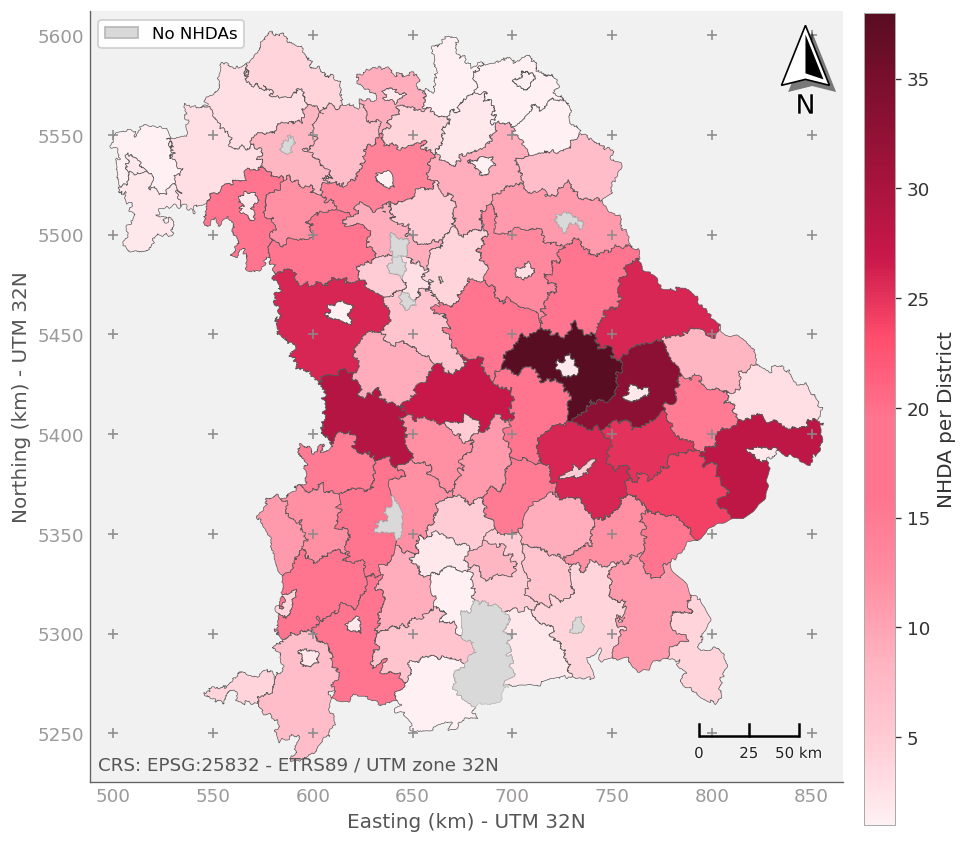

NHDA per Landkreis – min: 1, max: 38
Saved map: C:\Users\agz90fk\Documents\Masterarbeit\06_Abbildungen\nhda_per_landkreis_bayern.jpg


In [5]:
"""
NHDA count per Landkreis – choropleth map.
Color scale: #e4c2eb → #af92b5 → #6f597a → #503d5c
Depends on cell 1 having been executed (gdf_lk, gdf_nhda_centroids, helpers).
"""

import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch

OUTPUT_MAP_LK = OUTPUT_DIR / "nhda_per_landkreis_bayern.jpg"

COLOR_THEME_PURPLE = ['#fff0f3', '#ffccd5',  '#ffb3c1',  '#ff8fa3',  '#ff758f', '#ff758f', '#ff4d6d', "#c9184a", "#a4133c","#800f2f", "#590d22"]

CMAP_PURPLE = LinearSegmentedColormap.from_list("nhda_purple", COLOR_THEME_PURPLE)

# ---------------------------------------------------------------------------
# Count NHDA centroids per Landkreis
# ---------------------------------------------------------------------------
gdf_lk_plot = gdf_lk.copy()

joined = gpd.sjoin(
    gdf_nhda_centroids[["geometry"]],
    gdf_lk_plot[["geometry"]],
    how="left",
    predicate="within",
)
counts = joined.groupby("index_right").size().rename("nhda_count")
gdf_lk_plot = gdf_lk_plot.join(counts, how="left")
gdf_lk_plot["nhda_count"] = gdf_lk_plot["nhda_count"].fillna(0).astype(int)

# Neue Spalte für Plotting: 0 → NaN (wird mit missing_kwds in Grau dargestellt)
gdf_lk_plot["nhda_count_plot"] = gdf_lk_plot["nhda_count"].replace(0, np.nan)

# vmin/vmax nur von Werten > 0 berechnen
nonzero_counts = gdf_lk_plot[gdf_lk_plot["nhda_count"] > 0]["nhda_count"]
vmin = int(nonzero_counts.min())
vmax = int(nonzero_counts.max())
norm = Normalize(vmin=vmin, vmax=vmax)

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8.6, 9.4))
fig2.subplots_adjust(right=0.80, left=0.07, top=0.92, bottom=0.08)

gdf_lk_plot.plot(
    ax=ax2,
    column="nhda_count_plot",
    cmap=CMAP_PURPLE,
    norm=norm,
    linewidth=0.4,
    edgecolor="#555555",
    legend=False,
    zorder=2,
    missing_kwds={"color": "#d9d9d9", "edgecolor": "#b7b7b7", "label": "No NHDAs"},
)



add_north_arrow(ax2)
add_scale_bar(ax2)
add_scientific_frame(ax2, gdf_lk_plot)

# Colorbar in right margin
sm = ScalarMappable(cmap=CMAP_PURPLE, norm=norm)
sm.set_array([])
cbar_ax = fig2.add_axes([0.82, 0.12, 0.03, 0.72])
cbar = fig2.colorbar(sm, cax=cbar_ax)
cbar.set_label("NHDA per District", fontsize=12, color="#333333")
cbar.ax.tick_params(labelsize=11, colors="#333333")
cbar.outline.set_edgecolor("#aaaaaa")
cbar.outline.set_linewidth(0.6)

missing_handle = Patch(facecolor="#d9d9d9", edgecolor="#b7b7b7", label="No NHDAs")
ax2.legend(handles=[missing_handle], loc="upper left", frameon=True, framealpha=0.95, facecolor="white", edgecolor="#cccccc", fontsize=10)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_MAP_LK, bbox_inches="tight", facecolor="white", format="jpg")
plt.show()

print(f"NHDA per Landkreis – min: {vmin}, max: {vmax}")
print(f"Saved map: {OUTPUT_MAP_LK}")

In [13]:
# ---------------------------------------------------------------------------
# Which Landkreis has the most / fewest NHDA, and which have none?
# Depends on cell 2 having been executed (gdf_lk_plot with nhda_count).
# ---------------------------------------------------------------------------

NAME_COL = "GeografischerName_GEN"
BEZ_COL = "Bezeichnung"
ARS_COL = COL_ARS  # "Regionalschlüssel_ARS" from cell 1

cols = [c for c in [ARS_COL, NAME_COL, BEZ_COL, "nhda_count"] if c in gdf_lk_plot.columns]
summary = gdf_lk_plot[cols].copy().sort_values("nhda_count", ascending=False).reset_index(drop=True)

print("=== Top 10 Landkreise (meiste NHDA) ===")
print(summary.head(10).to_string(index=False))

print("\n=== Bottom 10 Landkreise (wenigste NHDA, excl. 0) ===")
nonzero = summary[summary["nhda_count"] > 0]
print(nonzero.tail(10).to_string(index=False))

print("\n=== Landkreise ohne NHDA ===")
no_nhda = summary[summary["nhda_count"] == 0]
if no_nhda.empty:
    print("Alle Landkreise haben mindestens eine NHDA.")
else:
    print(f"{len(no_nhda)} Landkreis(e) ohne NHDA:")
    print(no_nhda.to_string(index=False))


=== Top 10 Landkreise (meiste NHDA) ===
Regionalschlüssel_ARS GeografischerName_GEN Bezeichnung  nhda_count
                09375            Regensburg   Landkreis          38
                09278       Straubing-Bogen   Landkreis          33
                09779            Donau-Ries   Landkreis          29
                09275                Passau   Landkreis          28
                09176             Eichstätt   Landkreis          27
                09372                  Cham   Landkreis          26
                09274              Landshut   Landkreis          26
                09571               Ansbach   Landkreis          26
                09279     Dingolfing-Landau   Landkreis          25
                09277            Rottal-Inn   Landkreis          24

=== Bottom 10 Landkreise (wenigste NHDA, excl. 0) ===
Regionalschlüssel_ARS      GeografischerName_GEN      Bezeichnung  nhda_count
                09188                  Starnberg        Landkreis           1
 

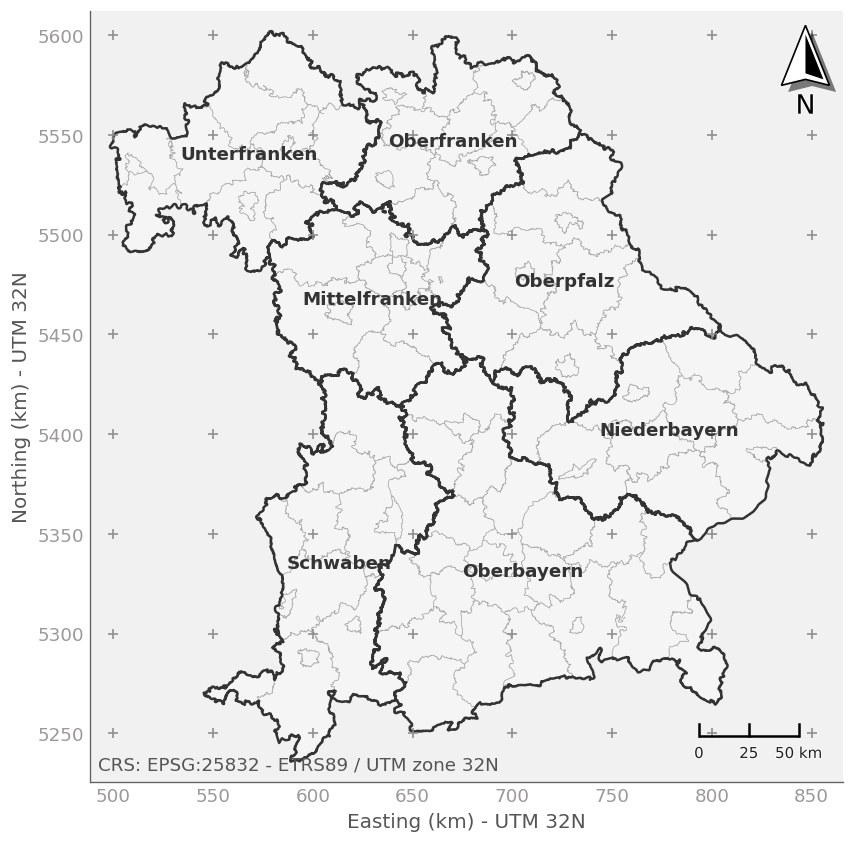

Saved: C:\Users\agz90fk\Documents\Masterarbeit\06_Abbildungen\regierungsbezirke_bavaria.jpg
